In [1]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# @title
import os

base_dir = "/content/drive/MyDrive/quant-projects"
project_dir = f"{base_dir}/var_cvar_risk_pipeline"
outputs_dir = f"{project_dir}/outputs"

os.makedirs(outputs_dir, exist_ok=True)

print("Base directory:", base_dir)
print("Project directory:", project_dir)
print("Outputs directory:", outputs_dir)

Base directory: /content/drive/MyDrive/quant-projects
Project directory: /content/drive/MyDrive/quant-projects/var_cvar_risk_pipeline
Outputs directory: /content/drive/MyDrive/quant-projects/var_cvar_risk_pipeline/outputs


In [3]:
# @title
readme_text = """# VaR / CVaR Risk Pipeline

A small Python project that estimates downside risk using historical, parametric, and Monte Carlo approaches.

## Project Overview
This project builds a simple risk analytics pipeline to compare Value at Risk (VaR) and Conditional Value at Risk (CVaR) under different methodologies.

## Methods Included
1. Historical VaR / CVaR
2. Parametric VaR / CVaR
3. Monte Carlo VaR / CVaR

## Additional Metrics
- Mean daily return
- Daily volatility
- Maximum drawdown

## Outputs
- risk_summary.csv
- portfolio_metrics.csv
- portfolio_returns_histogram.png
- cumulative_wealth.png
- drawdown.png

## Tools
- Python
- NumPy
- Pandas
- SciPy
- Matplotlib

## Notes
This is a simplified educational project and not a production-grade institutional risk engine.
"""

with open(f"{project_dir}/README.md", "w") as f:
    f.write(readme_text)

print("README.md created")

README.md created


               method       var      cvar
0          historical -0.020436 -0.030487
1          parametric -0.021863 -0.027050
2         monte_carlo -0.021792 -0.027031
3  daily_mean_returns -0.001448       NaN
4    daily_volatility  0.012412       NaN
5        max_drawdown -0.709815       NaN


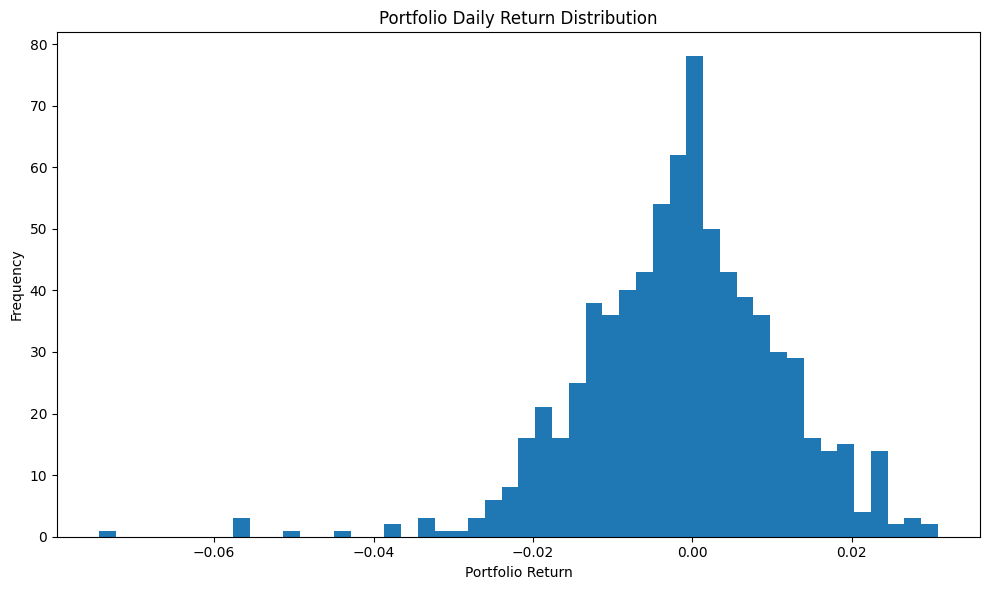

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def generate_portfolio_returns(n_days:int=756,seed:int=7):
  #756 trading days is equivalent to 3 years
  rng=np.random.default_rng(seed)
  #0.04%*252 is approx. 10% return a year with a volatility of approx.19% per annum.(1.2%*sq.root of 252). loc is mean and scale is standard
  #deviation
  base=rng.normal(loc=0.0004,scale=0.012,size=n_days)
  shock_mask=rng.random(n_days)<0.03#3% of days are shock days and 97% are normal days
  shocks=rng.normal(loc=-0.03,scale=0.04,size=n_days)
  #shocks show a sudden movement in the market with a mean of -3% and standard deviation of 4%
  returns=np.where(shock_mask,shocks,base)
  #in np.where(), the first argument is a condition, the function returns an array of elemnts from 2nd argument if condition is true and 3rd
  #argument if condition is false.
  return pd.Series(returns,name="portfolio return")

def historical_var_cvar(returns: pd.Series,confidence:float=0.95):
  var=np.percentile(returns,100*(1-confidence))
  cvar=returns[returns<=var].mean()
  return var,cvar

def parametric_var_cvar(returns: pd.Series,confidence:float=0.95):
  mu=returns.mean()
  sigma=returns.std(ddof=1)
  z=norm.ppf(1-confidence)
  var=mu+z*sigma
  cvar=mu-sigma*(norm.pdf(z)/(1-confidence))
  return var,cvar

def monte_carlo_var_cvar(returns:pd.Series,confidence:float=0.95,n_sim:int=100000,seed:int=21):
  rng=np.random.default_rng(seed)
  mu=returns.mean()
  sigma=returns.std(ddof=1)
  sims=rng.normal(mu,sigma,size=n_sim)
  var=np.percentile(sims,100*(1-confidence))
  cvar=sims[sims<=var].mean()
  return var,cvar

def max_drawdown(returns:pd.Series):
  wealth=(1+returns).cumprod()
  running_max=wealth.cummax()
  drawdown=wealth/running_max -1
  return drawdown.min()

def save_outputs(returns:pd.Series,summary_df:pd.DataFrame,output_dir:Path):
  output_dir.mkdir(parents=True,exist_ok=True)
  summary_df.to_csv(output_dir/"var_cvar_summary.csv",index=False)
  plt.figure(figsize=(10,6))
  plt.hist(returns,bins=50)
  plt.title("Portfolio Daily Return Distribution")
  plt.xlabel("Portfolio Return")
  plt.ylabel("Frequency")
  plt.tight_layout()
  plt.savefig(output_dir/"portfolio_return_distribution.png",dpi=150)
  plt.show()
  plt.close()

def main():
  output_dir=Path("/content/drive/MyDrive/quant-projects/var_cvar_risk_pipeline/outputs")
  confidence=0.95
  returns=generate_portfolio_returns()
  hist_var,hist_cvar=historical_var_cvar(returns,confidence)
  para_var,para_cvar=parametric_var_cvar(returns,confidence)
  monte_var,monte_cvar=monte_carlo_var_cvar(returns,confidence)
  summary_df=pd.DataFrame([
      {'method':'historical','var':hist_var,'cvar':hist_cvar},
      {'method':'parametric','var':para_var,'cvar':para_cvar},
      {'method':'monte_carlo','var':monte_var,'cvar':monte_cvar},
      {'method':'daily_mean_returns','var':returns.mean(),'cvar':np.nan},
      {'method':'daily_volatility','var':returns.std(ddof=1),'cvar':np.nan},
      {'method':'max_drawdown','var':max_drawdown(returns),'cvar':np.nan}
  ])
  print(summary_df)
  save_outputs(returns,summary_df,output_dir)

if __name__=="__main__":
  main()


In [5]:
# @title
!pip install numpy pandas matplotlib scipy
!python "/content/drive/MyDrive/quant-projects/var_cvar_risk_pipeline/risk_pipeline.py"


python3: can't open file '/content/drive/MyDrive/quant-projects/var_cvar_risk_pipeline/risk_pipeline.py': [Errno 2] No such file or directory


In [6]:
# @title
import os

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

var_cvar_risk_pipeline/
    README.md
    outputs/
        var_cvar_summary.csv
        portfolio_return_distribution.png
